# Experiment 3: Toy Superposition Phase Diagram

Proposal target: map phases over feature-frequency skew, lambda, and overcomplete dictionary size. This notebook uses the synthetic sparse-coding generator as a controlled toy superposition source with `N >> d`, feature probabilities `p_i ∝ i^{-alpha}`, and a lambda sweep.

The phase labels are operational proxies:
under-selected, monosemantic recovery, uncertain/interference, and overcomplete unstable. They are not metaphysical truth; they are diagnostics.


In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("cpu")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebooks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
from src.sae_data import SyntheticSparseCodingConfig, make_synthetic_sparse_coding
from src.sae_evaluate import decoder_recovery_cosine, support_precision_recall, vg_sae_observables
from src.sae_model import VGSAEConfig, VariationalGarroteSAE
from src.sae_train import fit_sae

input_dim = 8
width = 32
alphas = [0.0, 0.5, 1.0, 1.5]
lambdas = [0.0, 0.5, 1.0, 2.0, 3.0]
train_steps = 200


In [3]:
rows = []
for alpha in alphas:
    data = make_synthetic_sparse_coding(
        SyntheticSparseCodingConfig(
            input_dim=input_dim,
            n_features=width,
            n_samples=512,
            support_density=0.08,
            coherence=0.15,
            noise_std=0.03,
            frequency_skew=alpha,
            seed=10 + int(alpha * 10),
        ),
        device=DEVICE,
    )
    for lam in lambdas:
        model = VariationalGarroteSAE(
            VGSAEConfig(input_dim=input_dim, n_latents=width, lambda_sparsity=lam, beta=1.0)
        )
        fit_sae(model, data.x, max_steps=train_steps, batch_size=128, lr=3e-3, history_every=100, seed=0)
        obs = vg_sae_observables(model, data.x)
        precision, recall = support_precision_recall(model, data.x, data.support, data.dictionary)
        rows.append({
            "alpha": alpha,
            "lambda": lam,
            "mse": obs.mse,
            "rho": obs.rho,
            "v_eff": obs.v_eff,
            "entropy": obs.entropy,
            "interference_energy": obs.interference_energy,
            "dead_fraction": obs.dead_fraction,
            "decoder_recovery_cosine": decoder_recovery_cosine(model.decoder.weight, data.dictionary),
            "support_precision": precision,
            "support_recall": recall,
        })
df = pd.DataFrame(rows)
df.head()


,alpha,lambda,mse,rho,v_eff,entropy,interference_energy,dead_fraction,decoder_recovery_cosine,support_precision,support_recall
0,0.0,-1.0,0.072767,0.419061,0.194829,0.572083,13.080688,0.0,0.737140,0.121011,0.456818
1,0.0,0.0,0.069544,0.369484,0.201012,0.588466,9.596800,0.0,0.759948,0.137523,0.334848
2,0.0,1.0,0.138902,0.236378,0.174799,0.532508,3.637778,0.0,0.771923,0.302222,0.051515
3,0.0,2.0,0.222394,0.121537,0.104679,0.362332,0.985375,0.0,0.782042,0.481481,0.009848
4,0.0,3.0,0.326114,0.068076,0.062193,0.241182,0.327680,0.0,0.739988,0.461538,0.004545


In [4]:
mse_cut = df["mse"].median()
veff_cut = df["v_eff"].quantile(0.70)
recovery_cut = df["decoder_recovery_cosine"].median()

def assign_phase(row):
    if row["rho"] < 0.04 or row["mse"] > mse_cut * 1.25:
        return 0  # under-selected
    if row["mse"] <= mse_cut and row["v_eff"] <= veff_cut and row["decoder_recovery_cosine"] >= recovery_cut:
        return 1  # monosemantic recovery proxy
    if row["v_eff"] > veff_cut or row["interference_energy"] > df["interference_energy"].quantile(0.70):
        return 2  # uncertain/interference
    return 3  # unstable/ambiguous

df["phase"] = df.apply(assign_phase, axis=1)
phase_names = {
    0: "under-selected",
    1: "recovery",
    2: "uncertain/interference",
    3: "unstable/ambiguous",
}
df["phase_name"] = df["phase"].map(phase_names)
df


,alpha,lambda,mse,rho,v_eff,entropy,interference_energy,dead_fraction,decoder_recovery_cosine,support_precision,support_recall,phase,phase_name
0,0.0,-1.0,0.072767,0.419061,0.194829,0.572083,13.080688,0.0,0.737140,0.121011,0.456818,2,uncertain/interference
1,0.0,0.0,0.069544,0.369484,0.201012,0.588466,9.596800,0.0,0.759948,0.137523,0.334848,2,uncertain/interference
2,0.0,1.0,0.138902,0.236378,0.174799,0.532508,3.637778,0.0,0.771923,0.302222,0.051515,1,recovery
3,0.0,2.0,0.222394,0.121537,0.104679,0.362332,0.985375,0.0,0.782042,0.481481,0.009848,0,under-selected
4,0.0,3.0,0.326114,0.068076,0.062193,0.241182,0.327680,0.0,0.739988,0.461538,0.004545,0,under-selected
5,0.5,-1.0,0.108211,0.363827,0.177142,0.529797,9.710886,0.0,0.724403,0.113558,0.344725,2,uncertain/interference
6,0.5,0.0,0.104590,0.311534,0.185979,0.553714,6.561002,0.0,0.732015,0.142001,0.228826,3,unstable/ambiguous
7,0.5,1.0,0.149925,0.221940,0.166846,0.513869,2.965051,0.0,0.747049,0.345550,0.049034,3,unstable/ambiguous
8,0.5,2.0,0.228425,0.119705,0.102811,0.357283,0.875460,0.0,0.738470,0.553571,0.023031,0,under-selected
9,0.5,3.0,0.300587,0.075137,0.067912,0.259362,0.355897,0.0,0.743751,0.785714,0.016345,0,under-selected


,alpha,lambda,phase_name,v_eff,decoder_recovery_cosine,mse
0,0.0,-1.0,uncertain/interference,0.194829,0.737140,0.072767
1,0.0,0.0,uncertain/interference,0.201012,0.759948,0.069544
2,0.0,1.0,recovery,0.174799,0.771923,0.138902
3,0.0,2.0,under-selected,0.104679,0.782042,0.222394
4,0.0,3.0,under-selected,0.062193,0.739988,0.326114
5,0.5,-1.0,uncertain/interference,0.177142,0.724403,0.108211
6,0.5,0.0,unstable/ambiguous,0.185979,0.732015,0.104590
7,0.5,1.0,unstable/ambiguous,0.166846,0.747049,0.149925
8,0.5,2.0,under-selected,0.102811,0.738470,0.228425
9,0.5,3.0,under-selected,0.067912,0.743751,0.300587


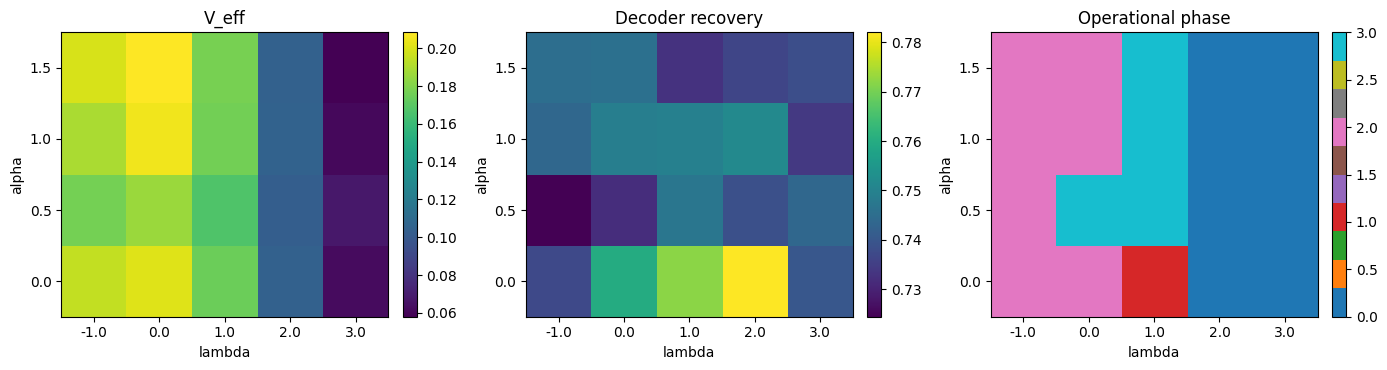

In [5]:
def heatmap(metric, ax, title, cmap="viridis"):
    pivot = df.pivot(index="alpha", columns="lambda", values=metric).sort_index()
    image = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap=cmap)
    ax.set_xticks(range(len(pivot.columns)), pivot.columns)
    ax.set_yticks(range(len(pivot.index)), pivot.index)
    ax.set_xlabel("lambda")
    ax.set_ylabel("alpha")
    ax.set_title(title)
    return image

out = OUTPUT_DIR / "exp03_toy_superposition"
out.mkdir(parents=True, exist_ok=True)
df.to_csv(out / "toy_superposition_phase_diagram.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for metric, ax, title in [
    ("v_eff", axes[0], "V_eff"),
    ("decoder_recovery_cosine", axes[1], "Decoder recovery"),
    ("phase", axes[2], "Operational phase"),
]:
    image = heatmap(metric, ax, title, cmap="tab10" if metric == "phase" else "viridis")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(out / "toy_superposition_phase_diagram.png", dpi=160)
df[["alpha", "lambda", "phase_name", "v_eff", "decoder_recovery_cosine", "mse"]]


**Physics sanity check:** a phase diagram earns the name only if the transition region is reproducible under seed and width changes. Treat this notebook as the first map, not the final territory.
